# Ноутбук 5. Uplift-модели: оценка индивидуального эффекта коммуникации

## Постановка задачи

В предыдущих ноутбуках построены две **классические скоринговые модели**:
- логистическая регрессия с WoE-кодированием (`logreg.ipynb`) — Gini ~33%;
- градиентный бустинг CatBoost (`cboost.ipynb`) — Gini ~55%.

Эти модели предсказывают **вероятность дефолта** $P(\text{дефолт} \mid X = x)$. Однако для CRM-таргетинга нас интересует принципиально другой вопрос:

> *Насколько изменится вероятность дефолта клиента, если мы с ним свяжемся?*

## Формализация: потенциальные исходы и CATE

В рамках **потенциальных исходов** (Potential Outcomes Framework, Rubin, 1974) определим **условный средний эффект воздействия** (Conditional Average Treatment Effect, CATE):

$$\tau_t(x) = \mathbb{E}[Y(t) - Y(0) \mid X = x]$$

где $Y(t)$ — потенциальный исход при коммуникации типа $t$ (SMS / звонок робота / звонок оператора), $Y(0)$ — потенциальный исход **без** коммуникации, $X$ — вектор признаков клиента.

**Фундаментальная проблема каузального вывода:** для каждого клиента наблюдается ровно один исход — он либо получил коммуникацию, либо нет. Оба потенциальных исхода одновременно ненаблюдаемы, поэтому $\tau_t(x)$ не может быть вычислена напрямую и требует специальных методов идентификации.

## Selection bias в CRM-данных

В реальных CRM-данных коммуникация назначается **не случайно**: банк звонит прежде всего рисковым клиентам. Это создаёт систематическую зависимость между признаками клиента и вероятностью получить воздействие:

$$P(T = t \mid X = x) \neq P(T = t)$$

Классические скоринговые модели «случайно» решают часть задачи таргетинга: поскольку высокорисковые клиенты одновременно и более рискованны, и чаще получают контакт, ранжирование по $P(\text{дефолт})$ воспроизводит порядок интенсивности коммуникации (что подтверждено AUUC 40–61% в разделе 13 cboost/logreg). Однако такой подход субоптимален: он не учитывает **гетерогенность эффекта** по клиентам и неспособен идентифицировать *Sleeping Dogs* — клиентов, у которых коммуникация ухудшает поведение.

## Уникальное преимущество синтетических данных

Поскольку датасет синтетический, переменная `TRUE_UPLIFT` известна для каждого клиента. Это позволяет применить **верификацию по ground truth**:
- ранговая корреляция предсказанного и истинного эффекта (Spearman $\rho$),
- calibration plot: предсказанный vs. истинный uplift по децилям.

В реальных данных такая верификация недоступна — это методологически сильный аргумент синтетического эксперимента, принятый в академической uplift-литературе как «золотой стандарт» оценки.

## Цели и исследовательские гипотезы

Ноутбук проверяет четыре конкретные гипотезы:

**Г1. Uplift meta-learner превосходят risk-based скоринг по AUUC.**
CatBoost (Gini ~55%) ранжирует клиентов по $P(\text{дефолт})$, неявно воспроизводя порядок интенсивности коммуникации из-за selection bias. Гипотеза: явная оценка $\hat{\tau}(x)$ даёт более высокий AUUC, поскольку учитывает гетерогенность эффекта, а не только уровень риска.

**Г2. DR-Learner превосходит S/T/X-Learner при явном selection bias.**
Selection bias намеренно заложен через `CONTACT_PROPENSITY` — коммуникация назначается по риску. Свойство двойной робастности DR-Learner должно устранять смещение, недостижимое для S/T-Learner без IPW-коррекции.

**Г3. При SNR 0.8–1.6 хотя бы один meta-learner даёт статистически значимый Spearman $\rho > 0$.**
Слабый сигнал не исключает значимой ранговой корреляции при $N = 307$k наблюдений. Гипотеза: объём выборки компенсирует низкий SNR — meta-learner статистически значимо различает клиентов по силе эффекта.

**Г4. S-Learner занижает эффект (attenuation bias) сильнее, чем двухмодельные подходы.**
В S-Learner treatment-признак конкурирует за сплиты с информативными кредитными признаками (`EXT_SOURCE`, `SK_DPD_MAX`). Гипотеза: AUUC и $|\rho|$ у S-Learner ниже, чем у T/X/DR-Learner.

---

## Структура ноутбука

1. Формализуем базовые стратегии и ограничения риск-ориентированного подхода (разделы 3–4).
2. Строим четыре **uplift meta-learner**: S-Learner (раздел 5), T-Learner (раздел 6), X-Learner (раздел 7), DR-Learner (раздел 8).
3. Сравниваем подходы по AUUC, % от оракула и Spearman $\rho$ (раздел 9) — **проверка Г1–Г4**.
4. Верифицируем результаты через `TRUE_UPLIFT` с calibration plots (раздел 10).

## 0. Импорты и настройки воспроизводимости

Устанавливается глобальный генератор случайных чисел `RANDOM_SEED = 91`. Все операции со случайностью — разбивка данных, обучение моделей, базовые стратегии — используют это значение, обеспечивая полную воспроизводимость эксперимента при повторном запуске ноутбука.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

RANDOM_SEED = 91
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_columns = 50


## 1. Загрузка данных и проверка ключевых полей

Загружается датасет из `data/processed/uplift-dataset.csv`, сформированный в `prepare_dataset.ipynb`. Проверяется наличие всех групп переменных:

| Группа | Примеры переменных | Роль |
|---|---|---|
| **Признаки клиента** | `DAYS_BIRTH`, `AMT_CREDIT`, `EXT_SOURCE_*` | Входы моделей |
| **Treatment** | `COMMUNICATION` | Тип воздействия: SMS / robot_call / operator_call / control |
| **Outcome** | `TARGET_AFTER_CONTACT` | Наблюдаемый бинарный исход (1 = дефолт) |
| **Oracle-поля** | `TRUE_UPLIFT`, `BASE_PD`, `PD_SMS` и др. | Истинный эффект — **только для оценки**, не в признаки |

**Защита от утечки данных:** oracle-поля (`TRUE_UPLIFT`, `BASE_PD`, `CONTACT_PROPENSITY`, `PD_NO_CONTACT` и др.) содержат информацию, недоступную на момент принятия решения о коммуникации. Они **исключаются из признакового пространства** всех моделей и используются исключительно для расчёта метрик качества в разделах 9–10.

In [2]:
import json

DATA_PATH = 'data/processed/uplift-dataset.csv'

df_full = pd.read_csv(DATA_PATH)
print(f'Датасет: {df_full.shape[0]:,} строк x {df_full.shape[1]} колонок')

leakage_cols = {
    'BASE_PD', 'CONTACT_PROPENSITY', 'RISK_SEGMENT',
    'CONTACT_HISTORY', 'PREFERRED_CHANNEL', 'INTERACTION_SCORE', 'DELAY_FLAG',
    'PD_NO_CONTACT', 'PD_SMS', 'PD_ROBOT_CALL', 'PD_OPERATOR_CALL',
    'UPLIFT_SMS', 'UPLIFT_ROBOT_CALL', 'UPLIFT_OPERATOR_CALL',
    'TRUE_UPLIFT', 'ORACLE_COMMUNICATION', 'ORACLE_TRUE_UPLIFT', 'ORACLE_PD_AFTER_CONTACT',
    'PD_AFTER_CONTACT',
}
oracle_cols = {'TRUE_UPLIFT', 'ORACLE_COMMUNICATION', 'ORACLE_TRUE_UPLIFT', 'ORACLE_PD_AFTER_CONTACT'}

outcome_col = 'TARGET_AFTER_CONTACT'

print('
Распределение по COMMUNICATION:')
print(df_full['COMMUNICATION'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print(f'
Доля дефолтов: {df_full[outcome_col].mean():.2%}')

Датасет: 307,511 строк x 173 колонок
ВНИМАНИЕ: файл ролей не найден, используется резервный список leakage-полей

Распределение по COMMUNICATION:
COMMUNICATION
control          90.1%
operator_call     5.7%
robot_call        2.5%
sms               1.7%
Name: proportion, dtype: object

Доля дефолтов: 7.73%


## 1.1. Инженерные признаки

Воспроизводятся те же преобразования, что применялись в `cboost.ipynb` и `logreg.ipynb`,
чтобы uplift-модели и risk-baseline использовали одинаковое признаковое пространство.

| Признак | Формула | Смысл |
|---|---|---|
| `AGE_YEARS` | $-\text{DAYS\_BIRTH}/365$ | Возраст клиента в годах |
| `EMPLOYMENT_YEARS` | $-\text{DAYS\_EMPLOYED}/365$ | Стаж работы в годах |
| `EMPLOYMENT_RATIO` | $\text{EMPLOYMENT\_YEARS}/\text{AGE\_YEARS}$ | Доля жизни в занятости |
| `CREDIT_HISTORY_LENGTH` | $\text{DAYS\_CREDIT\_MAX}-\text{DAYS\_CREDIT\_MIN}$ | Длина кредитной истории (дни) |
| `MONTHS_BALANCE_RANGE` | $\text{MONTHS\_BALANCE\_MIN}-\text{MONTHS\_BALANCE\_MEAN}$ | Разброс глубины кредитных записей |

In [3]:
# Инженерные признаки (идентично cboost.ipynb / logreg.ipynb)
df_full['AGE_YEARS']             = -df_full['DAYS_BIRTH'] / 365
df_full['EMPLOYMENT_YEARS']      = -df_full['DAYS_EMPLOYED'] / 365
df_full['EMPLOYMENT_RATIO']      = df_full['EMPLOYMENT_YEARS'] / df_full['AGE_YEARS']
df_full['CREDIT_HISTORY_LENGTH'] = df_full['DAYS_CREDIT_MAX'] - df_full['DAYS_CREDIT_MIN']
df_full['MONTHS_BALANCE_RANGE']  = df_full['MONTHS_BALANCE_MIN'] - df_full['MONTHS_BALANCE_MEAN']
print('Добавлено 5 инженерных признаков: AGE_YEARS, EMPLOYMENT_YEARS, EMPLOYMENT_RATIO, '
      'CREDIT_HISTORY_LENGTH, MONTHS_BALANCE_RANGE')

Добавлено 5 инженерных признаков: AGE_YEARS, EMPLOYMENT_YEARS, EMPLOYMENT_RATIO, CREDIT_HISTORY_LENGTH, MONTHS_BALANCE_RANGE


## 2. Разбивка на train / test / OOT

Используется та же разбивка, что и в классических моделях — **60% train / 20% test / 20% OOT**:

| Выборка | Доля | N наблюдений | Назначение |
|---|---|---|---|
| **Вневременная (OOT)** | 20% | ~61 500 | Оценка временно́й устойчивости моделей |
| **Обучающая** | 60% | ~184 500 | Обучение мета-лёрнеров и nuisance-моделей |
| **Тестовая** | 20% | ~61 500 | Независимая оценка качества |

Разбивка **псевдо-временна́я** (по порядку строк), воспроизводя структуру из `cboost.ipynb` и `logreg.ipynb`. Параметр `random_state=RANDOM_SEED` фиксирует все операции с перемешиванием.

**Бинаризация treatment:** помимо четырёхзначной метки `COMMUNICATION`, формируется бинарный индикатор $T_{\text{bin}} = \mathbf{1}[\text{COMMUNICATION} \neq \text{"control"}]$ — используется в X-Learner и DR-Learner, работающих с бинарной постановкой задачи воздействия.

In [4]:
import math

exclude_always = {'SK_ID_CURR', 'TARGET', outcome_col} | leakage_cols | {'COMMUNICATION'}
feature_cols = [
    c for c in df_full.columns
    if c not in exclude_always and df_full[c].dtype != object
]
print(f'Признаков для модели: {len(feature_cols)}')

n          = len(df_full)
oot_size   = math.ceil(n * 0.2)
train_size = math.ceil((n - oot_size) * 0.75)

oot   = df_full.iloc[:oot_size].copy()
rest  = df_full.iloc[oot_size:].copy()
train = rest.iloc[:train_size].copy()
test  = rest.iloc[train_size:].copy()

print(f'train: {len(train):,} ({len(train)/n:.0%}) | test: {len(test):,} ({len(test)/n:.0%}) | OOT: {len(oot):,} ({len(oot)/n:.0%})')

X_train = train[feature_cols].fillna(-999)
X_test  = test[feature_cols].fillna(-999)
X_oot   = oot[feature_cols].fillna(-999)

y_train = train[outcome_col].values
y_test  = test[outcome_col].values
y_oot   = oot[outcome_col].values

T_train = train['COMMUNICATION'].values
T_test  = test['COMMUNICATION'].values
T_oot   = oot['COMMUNICATION'].values

t_train_bin = (T_train != 'control').astype(int)
t_test_bin  = (T_test  != 'control').astype(int)
t_oot_bin   = (T_oot   != 'control').astype(int)

print(f'Доля дефолтов: train={y_train.mean():.3%}, test={y_test.mean():.3%}, OOT={y_oot.mean():.3%}')


Признаков для модели: 139
train: 184,506 (60%) | test: 61,502 (20%) | OOT: 61,503 (20%)
Доля дефолтов: train=7.768%, test=7.753%, OOT=7.588%


## 2.1. Risk-baseline модели

Для корректного сравнения подходов формируются **четыре риск-ориентированных baseline**:

| Модель | Признаки | Target | Источник |
|---|---|---|---|
| **CatBoost (22-отобр., TARGET)** | 22 отобранных (SHAP + IV) + engineering | `TARGET` (ориг.) | загрузка `cboost.cbm` |
| **CatBoost (все feat, TARGET)** | все 139 числовых + 16 категориальных | `TARGET` (ориг.) | обучение здесь |
| **LogReg (8 WoE, TARGET)** | 8 WoE-бинированных | `TARGET` (ориг.) | загрузка `logreg.pkl` |
| **LogReg (все feat, TARGET)** | все 139 числовых, StandardScaler | `TARGET` (ориг.) | обучение здесь |

Все risk-модели обучены на `TARGET` (оригинальная метка дефолта Home Credit) — это воспроизводит
**реальный сценарий**: bank имеет production-модель риска и применяет её для CRM-таргетинга.
Uplift-модели обучаются на `TARGET_AFTER_CONTACT` (синтетический исход с коммуникацией).
Все модели оцениваются по **AUUC на `TARGET_AFTER_CONTACT`**.

In [5]:
import pickle, os
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Загрузка сохранённых моделей ──────────────────────────────────────────────
with open('models/cboost/features.json', encoding='utf-8') as f:
    cb_saved_feats = json.load(f)
with open('models/logreg/features.json', encoding='utf-8') as f:
    lr_saved_feats = json.load(f)

cb_saved = CatBoostClassifier()
cb_saved.load_model('models/cboost/cboost.cbm')

lr_saved_bp = pickle.load(open('models/logreg/binning_process.pkl', 'rb'))
lr_saved_lr = pickle.load(open('models/logreg/logreg.pkl', 'rb'))

# Категориальные признаки для cboost.cbm
cb_saved_cat = [f for f in cb_saved_feats if f in df_full.columns and df_full[f].dtype == object]

def _cb_saved_pred(df_split):
    X = df_split[cb_saved_feats].copy().fillna(-999)
    for c in cb_saved_cat:
        X[c] = X[c].fillna('missing').astype(str)
    return cb_saved.predict_proba(X)[:, 1]

def _lr_saved_pred(df_split):
    X = df_split[lr_saved_feats].fillna(-999)
    return lr_saved_lr.predict_proba(lr_saved_bp.transform(X))[:, 1]

cb_saved_score_test = _cb_saved_pred(test)
cb_saved_score_oot  = _cb_saved_pred(oot)
lr_saved_score_test = _lr_saved_pred(test)
lr_saved_score_oot  = _lr_saved_pred(oot)

# ── CatBoost на всех признаках (TARGET) ───────────────────────────────────────
cat_cols_all = [c for c in df_full.columns
                if c not in (set(feature_cols) | {'SK_ID_CURR','TARGET',outcome_col,'COMMUNICATION'}
                             | leakage_cols)
                and df_full[c].dtype == object]

def _make_cb_all_X(df_split):
    return pd.concat([
        df_split[feature_cols].fillna(-999).reset_index(drop=True),
        df_split[cat_cols_all].fillna('missing').astype(str).reset_index(drop=True)
    ], axis=1)

X_train_cba = _make_cb_all_X(train)
X_test_cba  = _make_cb_all_X(test)
X_oot_cba   = _make_cb_all_X(oot)
cat_idx_all = list(range(len(feature_cols), len(feature_cols) + len(cat_cols_all)))

y_train_orig = train['TARGET'].values
y_test_orig  = test['TARGET'].values

cb_all = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    cat_features=cat_idx_all,
    random_seed=RANDOM_SEED, verbose=0,
    eval_metric='AUC', early_stopping_rounds=50,
)
cb_all.fit(X_train_cba, y_train_orig, eval_set=(X_test_cba, y_test_orig))

cb_all_score_test = cb_all.predict_proba(X_test_cba)[:, 1]
cb_all_score_oot  = cb_all.predict_proba(X_oot_cba)[:, 1]

# ── LogReg на всех числовых признаках (TARGET) ────────────────────────────────
lr_all = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)),
])
lr_all.fit(X_train, y_train_orig)
lr_all_score_test = lr_all.predict_proba(X_test)[:, 1]
lr_all_score_oot  = lr_all.predict_proba(X_oot)[:, 1]

# ── Качество risk-моделей на TARGET ───────────────────────────────────────────
print(f'{"Модель":<30} {"Gini (TARGET, test)":>20}')
print('-' * 53)
for name, pred in [
    ('CatBoost (22-отобр., TARGET)', cb_saved_score_test),
    ('CatBoost (все feat, TARGET)',  cb_all_score_test),
    ('LogReg (8 WoE, TARGET)',       lr_saved_score_test),
    ('LogReg (все feat, TARGET)',    lr_all_score_test),
]:
    auc = roc_auc_score(y_test_orig, pred)
    print(f'{name:<30} {2*auc-1:>20.4f}')

(CVXPY) May 09 02:20:13 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 09 02:20:13 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=0]="Cash loans": Cannot convert 'Cash loans' to float

## 3. Qini-кривая и AUUC — основная метрика качества uplift-моделей

**Qini-кривая** — стандартная метрика оценки uplift-стратегий. Построение:

1. Клиенты сортируются по убыванию предсказанного uplift-скора $s(x)$.
2. Для каждой доли $\tau$ охваченных клиентов вычисляется накопленный эффект коммуникации относительно контрольной группы:

$$Q(\tau) = \frac{\displaystyle\sum_{i \in \text{top-}\tau,\, T_i=1} Y_i}{N_T} - \frac{\displaystyle\sum_{i \in \text{top-}\tau,\, T_i=0} Y_i}{N_C} \cdot \frac{|\{i \in \text{top-}\tau : T_i=1\}|}{N_T}$$

**AUUC** (Area Under Uplift Curve) — площадь между Qini-кривой модели и базовой линией случайного ранжирования:

$$\text{AUUC} = \int_0^1 \bigl[Q_\text{модель}(\tau) - Q_\text{случайн.}(\tau)\bigr]\,d\tau, \qquad Q_\text{случайн.}(\tau) = \tau \cdot Q(1)$$

**Знак uplift:** `TRUE_UPLIFT` отрицательный означает снижение PD (желаемый эффект коммуникации). Поэтому ранжирующий скор: $s(x) = -\hat{\tau}(x)$ — клиенты с наибольшим снижением PD получают наивысший приоритет.

**Относительная эффективность** $\eta = \text{AUUC}_\text{модель} / \text{AUUC}_\text{оракул} \cdot 100\%$ показывает, какую долю теоретически достижимого uplift реализует модель.

In [ ]:
def compute_qini(y, treatment, score, n_bins=100):
    """Вычисляет Qini-кривую и AUUC для оценки качества uplift-ранжирования.

    Параметры
    ----------
    y : array-like
        Целевая переменная (1 = дефолт).
    treatment : array-like
        Бинарный флаг коммуникации (1 = контакт, 0 = контроль).
    score : array-like
        Скор ранжирования; клиенты сортируются по убыванию.
    n_bins : int, по умолчанию 100
        Число точек Qini-кривой.

    Возвращает
    ----------
    tuple[ndarray, ndarray, ndarray, float]
        (fracs, qini_vals, random_vals, auuc).
        fracs — доли охваченных клиентов; qini_vals — значения Qini;
        random_vals — baseline случайного ранжирования; auuc — площадь между кривой и baseline.
    """
    df_q = pd.DataFrame({'y': y, 't': treatment, 'score': score})
    df_q = df_q.sort_values('score', ascending=False).reset_index(drop=True)

    n_ctrl = int((1 - treatment).sum())
    if n_ctrl == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0]), np.array([0.0, 0.0]), 0.0

    fracs, qini_vals = [0.0], [0.0]
    step = max(1, len(df_q) // n_bins)
    for k in range(step, len(df_q) + 1, step):
        top_k = df_q.iloc[:k]
        t1 = top_k[top_k['t'] == 1]
        t0 = top_k[top_k['t'] == 0]
        if len(t0) == 0:
            continue
        qini = t1['y'].sum() - t0['y'].sum() * (len(t1) / n_ctrl)
        fracs.append(k / len(df_q))
        qini_vals.append(qini)

    full_qini = qini_vals[-1] if qini_vals else 0.0
    random_vals = [f * full_qini for f in fracs]
    auuc = np.trapz(qini_vals, fracs) - np.trapz(random_vals, fracs)
    return np.array(fracs), np.array(qini_vals), np.array(random_vals), auuc


## 4. Базовые стратегии — точки отсчёта

Фиксируем наивные стратегии как точки калибровки для последующего сравнения.

| Стратегия | Скор ранжирования | Смысл |
|---|---|---|
| Никого не контактировать | $s(x) = 0$ | Нижняя граница: нулевые затраты |
| Случайный выбор | $s(x) \sim \mathrm{Uniform}(0,1)$ | Нулевая информация о клиенте |
| Risk-based | $s(x) = P(\text{дефолт})$ | Текущая практика кредитных организаций |
| Oracle | $s(x) = -\text{TRUE\_UPLIFT}$ | Теоретический верхний предел |

**Типология клиентов по реакции на воздействие** (Persuadables framework):

| Тип | Описание | Оптимальное действие |
|---|---|---|
| **Persuadables** | Платят *только* при получении коммуникации | Контактировать — максимальный эффект |
| **Sure Things** | Платят в любом случае | Не контактировать — пустые затраты |
| **Sleeping Dogs** | Коммуникация *ухудшает* поведение ($\tau > 0$) | Не контактировать — отрицательный эффект |
| **Lost Causes** | Не платят ни при каком исходе | Не контактировать — бесполезно |

**Почему риск-ориентированный скоринг субоптимален:** высокорисковый клиент — это зачастую *Lost Cause* (не поможет никакая коммуникация) или *Sleeping Dog*. Uplift-модель нацелена на идентификацию *Persuadables* **независимо от их абсолютного уровня риска**, что принципиально отличает её от риск-скоринга.

In [ ]:
rng = np.random.RandomState(RANDOM_SEED)

scores_baselines = {
    'Случайный выбор':                rng.rand(len(y_test)),
    'BASE_PD (синтетич.)':            test['BASE_PD'].values,
    'CatBoost (22-отобр., TARGET)':   cb_saved_score_test,
    'CatBoost (все feat, TARGET)':    cb_all_score_test,
    'LogReg (8 WoE, TARGET)':         lr_saved_score_test,
    'LogReg (все feat, TARGET)':      lr_all_score_test,
    'Oracle (TRUE_UPLIFT)':          -test['TRUE_UPLIFT'].values,
}
scores_baselines_oot = {
    'Случайный выбор':                np.random.RandomState(RANDOM_SEED+1).rand(len(y_oot)),
    'BASE_PD (синтетич.)':            oot['BASE_PD'].values,
    'CatBoost (22-отобр., TARGET)':   cb_saved_score_oot,
    'CatBoost (все feat, TARGET)':    cb_all_score_oot,
    'LogReg (8 WoE, TARGET)':         lr_saved_score_oot,
    'LogReg (все feat, TARGET)':      lr_all_score_oot,
    'Oracle (TRUE_UPLIFT)':          -oot['TRUE_UPLIFT'].values,
}

print(f'{"Стратегия":<35} {"AUUC (test)":>12} {"AUUC (OOT)":>12}')
print('-' * 62)
baseline_auuc = {}
for name in scores_baselines:
    _, _, _, auuc_t = compute_qini(y_test, t_test_bin, scores_baselines[name])
    _, _, _, auuc_o = compute_qini(y_oot,  t_oot_bin,  scores_baselines_oot[name])
    baseline_auuc[name] = auuc_t
    print(f'{name:<35} {auuc_t:>12.6f} {auuc_o:>12.6f}')

---

## 5. S-Learner (Single-Model Approach)

### Идея метода

**S-Learner** — наиболее простой мета-лёрнер: тип коммуникации добавляется как обычный признак, и обучается **единственная** базовая модель $\hat{\mu}(x, t)$:

$$\hat{\mu}(x, t) = \mathbb{E}[Y \mid X = x,\, T = t]$$

Предсказанный uplift для канала $t$ относительно контрольной группы:

$$\hat{\tau}_t(x) = \hat{\mu}(x,\, t) - \hat{\mu}(x,\, \text{control})$$

**Реализация:** `COMMUNICATION` кодируется one-hot и добавляется к матрице признаков. После обучения CatBoost делаются два предсказания на одних и тех же клиентских признаках — с $T = t$ и с $T = \text{control}$ — и берётся разность.

### Когда применять

| Сценарий | Пригодность | Обоснование |
|---|---|---|
| Сбалансированные группы treatment/control | ✓ Хорошо | Все группы вносят равный вклад в обучение |
| Сильный сигнал ($\text{SNR} > 3$) | ✓ Хорошо | Эффект явно различим на фоне шума |
| Слабый сигнал ($\text{SNR} \sim 1$) | ✗ Риск | Treatment «тонет» среди более значимых признаков |
| Малые группы воздействия ($< 5\%$) | ✗ Риск | Признак treatment почти не влияет на дерево-сплиты |

### Ожидаемые результаты в данном эксперименте

При SNR 0.8–1.6 S-Learner рискует «растворить» эффект коммуникации среди информативных кредитных признаков — CatBoost в первую очередь опирается на `DAYS_BIRTH`, `DAYS_CREDIT_MEAN`, `SK_DPD_MAX_POS`, а не на treatment-признак со слабым сигналом. Это **ожидаемое поведение** метода при низком SNR и является одним из мотивов перехода к двухмодельным подходам.

In [ ]:
from catboost import CatBoostClassifier

# One-hot кодируем treatment
comm_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
comm_encoder.fit(T_train.reshape(-1, 1))

def add_treatment_ohe(X_df, T_arr, encoder):
    """Присоединяет one-hot представление treatment к матрице признаков клиента.

    Параметры
    ----------
    X_df : DataFrame
        Матрица клиентских признаков.
    T_arr : ndarray
        Массив строковых меток канала коммуникации.
    encoder : OneHotEncoder
        Обученный кодировщик treatment-меток.

    Возвращает
    ----------
    DataFrame
        Матрица признаков с добавленными колонками COMM_<channel>.
    """
    t_enc = encoder.transform(T_arr.reshape(-1, 1))
    t_df  = pd.DataFrame(t_enc,
                          columns=[f'COMM_{c}' for c in encoder.categories_[0]],
                          index=range(len(X_df)))
    return pd.concat([X_df.reset_index(drop=True), t_df], axis=1)

X_train_s = add_treatment_ohe(X_train, T_train, comm_encoder)
X_test_s  = add_treatment_ohe(X_test,  T_test,  comm_encoder)
X_oot_s   = add_treatment_ohe(X_oot,   T_oot,   comm_encoder)

# Обучение S-Learner на CatBoost
s_model = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=RANDOM_SEED, verbose=0,
    eval_metric='AUC', early_stopping_rounds=50,
)
s_model.fit(X_train_s, y_train, eval_set=(X_test_s, y_test))

auc_s = roc_auc_score(y_test, s_model.predict_proba(X_test_s)[:, 1])
print(f'S-Learner AUC (test): {auc_s:.4f}  |  Gini: {2*auc_s-1:.4f}')


S-Learner AUC (test): 0.8283  |  Gini: 0.6566


In [ ]:
channels_list = ['sms', 'robot_call', 'operator_call']

def s_learner_uplift_per_channel(model, X_df, encoder, channels):
    """Вычисляет uplift S-Learner по каждому каналу коммуникации.

    Параметры
    ----------
    model : CatBoostClassifier
        Единая обученная модель исходов hat_mu(x, t).
    X_df : DataFrame
        Матрица клиентских признаков (без treatment-признаков).
    encoder : OneHotEncoder
        Кодировщик treatment-меток, применявшийся при обучении.
    channels : list of str
        Каналы воздействия для расчёта uplift.

    Возвращает
    ----------
    dict
        Ключи — названия каналов + 'best'.
        hat_tau_t(x) = hat_mu(x, t) - hat_mu(x, control).
        'best' — поэлементный минимум по каналам (наибольшее снижение PD).
    """
    X_ctrl = add_treatment_ohe(X_df, np.array(['control'] * len(X_df)), encoder)
    p_ctrl = model.predict_proba(X_ctrl)[:, 1]
    uplift = {}
    for ch in channels:
        X_ch = add_treatment_ohe(X_df, np.array([ch] * len(X_df)), encoder)
        uplift[ch] = model.predict_proba(X_ch)[:, 1] - p_ctrl
    uplift_matrix = pd.DataFrame({ch: uplift[ch] for ch in channels})
    uplift['best'] = uplift_matrix.min(axis=1).values
    return uplift

uplift_s_test = s_learner_uplift_per_channel(s_model, X_test, comm_encoder, channels_list)
uplift_s_oot  = s_learner_uplift_per_channel(s_model, X_oot,  comm_encoder, channels_list)

score_s_test = -uplift_s_test['best']
score_s_oot  = -uplift_s_oot['best']

_, _, _, auuc_s_test = compute_qini(y_test, t_test_bin, score_s_test)
_, _, _, auuc_s_oot  = compute_qini(y_oot,  t_oot_bin,  score_s_oot)
oracle_auuc = baseline_auuc['Oracle (TRUE_UPLIFT)']

print(f'S-Learner AUUC: test={auuc_s_test:.6f}  |  OOT={auuc_s_oot:.6f}')
print(f'Относительная эффективность: {auuc_s_test/oracle_auuc*100:.1f}% от оракула')


S-Learner AUUC: test=332.117948  |  OOT=342.576123
Относительная эффективность: 80.2% от оракула


---

## 6. T-Learner (Two-Model Approach)

### Идея метода

**T-Learner** обучает **отдельную модель на каждую группу** treatment и control:

$$\hat{\mu}_t(x) = P(Y = 1 \mid X = x,\, T = t), \quad \hat{\mu}_0(x) = P(Y = 1 \mid X = x,\, T = \text{control})$$

Предсказанный uplift:

$$\hat{\tau}_t(x) = \hat{\mu}_t(x) - \hat{\mu}_0(x)$$

**Ключевое преимущество перед S-Learner:** каждая модель специализируется исключительно на своей подгруппе и **не конкурирует** с кредитными признаками за объяснительную силу treatment-переменной. Даже при слабом сигнале модель $\hat{\mu}_t$ может уловить специфику клиентов, получивших канал $t$, поскольку treatment не присутствует явно в признаковом пространстве.

### Когда применять

| Сценарий | Пригодность | Обоснование |
|---|---|---|
| Разные механизмы воздействия по каналам | ✓ Оптимально | Каждая модель улавливает специфику своего канала |
| Гетерогенный эффект по сегментам | ✓ Хорошо | Модели не усредняют эффект по каналам |
| Умеренный дисбаланс (50/50–80/20) | ✓ Приемлемо | Достаточно данных для каждой модели |
| Сильный дисбаланс ($> 90/10$) | ✗ Риск | Модель меньшей группы нестабильна |
| Нет selection bias | ✓ Хорошо | Разностная оценка не накапливает смещения |

### Особенности для наших данных

В синтетическом датасете заложена **сегментная специфика**: SMS эффективен для low-risk-клиентов ($\tau_\text{SMS} \approx -0.005$), operator_call — для high-risk ($\tau_\text{op} \approx -0.035$). T-Learner с раздельными моделями на каждый канал должен улавливать этот паттерн лучше, чем единая S-модель. Превосходство T-Learner над S-Learner по AUUC будет подтверждением наличия гетерогенного канального эффекта.

### Ограничение: дисбаланс групп

Группы несбалансированы (operator_call — ~25%, control — ~30%). При более сильном дисбалансе модель меньшей группы имеет более высокую дисперсию оценок $\hat{\mu}_t(x)$, что делает разностную оценку $\hat{\tau}_t(x)$ нестабильной. Для этого случая разработан X-Learner (раздел 7).

In [ ]:
# Обучаем по одной CatBoost-модели на каждый treatment
t_models = {}
print('Обучение T-Learner (одна модель на каждый treatment):')
for treatment_name in ['control'] + channels_list:
    mask = T_train == treatment_name
    n_tr = mask.sum()
    m = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6,
                            random_seed=RANDOM_SEED, verbose=0)
    m.fit(X_train[mask], y_train[mask])
    t_models[treatment_name] = m
    mask_t = T_test == treatment_name
    if mask_t.sum() > 50:
        auc = roc_auc_score(y_test[mask_t], m.predict_proba(X_test[mask_t])[:, 1])
        print(f'  {treatment_name:<16}  n_train={n_tr:>6,}  AUC={auc:.4f}')
    else:
        print(f'  {treatment_name:<16}  n_train={n_tr:>6,}  (мало данных в test)')


Обучение T-Learner (одна модель на каждый treatment):
  control           n_train=166,215  AUC=0.8121
  sms               n_train= 3,133  AUC=0.3774
  robot_call        n_train= 4,591  AUC=0.5560
  operator_call     n_train=10,567  AUC=0.7772


In [ ]:
def t_learner_uplift(models, X_df, channels):
    """Вычисляет uplift T-Learner: разность предсказаний канальной и контрольной моделей.

    Параметры
    ----------
    models : dict
        Словарь обученных CatBoostClassifier: ключ — название канала или 'control'.
    X_df : DataFrame
        Матрица клиентских признаков.
    channels : list of str
        Каналы воздействия для расчёта uplift.

    Возвращает
    ----------
    dict
        Uplift-оценки по каналам + 'best'.
        hat_tau_t(x) = hat_mu_t(x) - hat_mu_0(x).
    """
    p_ctrl = models['control'].predict_proba(X_df)[:, 1]
    uplift = {}
    for ch in channels:
        uplift[ch] = models[ch].predict_proba(X_df)[:, 1] - p_ctrl
    uplift_matrix = pd.DataFrame({ch: uplift[ch] for ch in channels})
    uplift['best'] = uplift_matrix.min(axis=1).values
    return uplift

uplift_t_test = t_learner_uplift(t_models, X_test, channels_list)
uplift_t_oot  = t_learner_uplift(t_models, X_oot,  channels_list)

score_t_test = -uplift_t_test['best']
score_t_oot  = -uplift_t_oot['best']

_, _, _, auuc_t_test = compute_qini(y_test, t_test_bin, score_t_test)
_, _, _, auuc_t_oot  = compute_qini(y_oot,  t_oot_bin,  score_t_oot)
print(f'T-Learner AUUC: test={auuc_t_test:.6f}  |  OOT={auuc_t_oot:.6f}')
print(f'Относительная эффективность: {auuc_t_test/oracle_auuc*100:.1f}% от оракула')


T-Learner AUUC: test=359.981552  |  OOT=367.639755
Относительная эффективность: 87.0% от оракула


---

## 7. X-Learner

### Идея метода

**X-Learner** (Künzel et al., 2019) разработан специально для **несбалансированных групп** treatment/control — типичная ситуация в CRM, где контрольная группа на порядок превышает treated-группу. Название отражает «перекрёстную» (cross) импутацию псевдо-эффектов.

### Алгоритм

**Шаг 1.** Базовые outcome-модели (идентично T-Learner):

$$\hat{\mu}_1(x) = P(Y \mid X = x,\, T = 1), \quad \hat{\mu}_0(x) = P(Y \mid X = x,\, T = 0)$$

**Шаг 2.** Псевдо-эффект для каждого клиента — «импутированный» индивидуальный каузальный эффект:

$$\tilde{\tau}_i^{(1)} = Y_i - \hat{\mu}_0(X_i) \quad \text{(для группы воздействия, }T_i=1\text{)}$$
$$\tilde{\tau}_j^{(0)} = \hat{\mu}_1(X_j) - Y_j \quad \text{(для контрольной группы, }T_j=0\text{)}$$

Здесь $\hat{\mu}_0(X_i)$ — предсказанный исход для treated-клиента $i$ в случае **отсутствия** воздействия (контрфактуал). Разность $Y_i - \hat{\mu}_0(X_i)$ оценивает индивидуальный эффект для клиента $i$.

**Шаг 3.** Регрессоры на псевдо-эффектах:

$$\hat{\tau}_1(x) \leftarrow \mathrm{fit}\bigl(\tilde{\tau}^{(1)} \sim X \mid T=1\bigr), \quad \hat{\tau}_0(x) \leftarrow \mathrm{fit}\bigl(\tilde{\tau}^{(0)} \sim X \mid T=0\bigr)$$

**Шаг 4.** Взвешенное смешение через propensity score $g(x) = P(T=1 \mid X=x)$:

$$\hat{\tau}(x) = g(x) \cdot \hat{\tau}_0(x) + \bigl(1 - g(x)\bigr) \cdot \hat{\tau}_1(x)$$

### Интерпретация взвешивания

Когда $g(x) \approx 0$ (большинство «похожих» клиентов — в контроле): итоговая оценка опирается на $\hat{\tau}_1(x)$, построенный на treated-группе, более информативной для таких клиентов. Когда $g(x) \approx 1$ — наоборот. Это снижает **дисперсию** итоговой оценки по сравнению с T-Learner при сильном дисбалансе.

### Когда применять

| Сценарий | Пригодность | Обоснование |
|---|---|---|
| Сильный дисбаланс ($> 90/10$) | ✓ Разработан для этого | Propensity-взвешивание стабилизирует оценку |
| Treated-группа 5–20% | ✓ Основной сценарий | Классический CRM-сценарий |
| Пропорциональные группы | ○ Работает, преимущество мало | T-Learner эквивалентен |
| Ненулевой propensity score | ✓ Учитывает selection bias | $g(x)$ корректирует разностную оценку |

In [ ]:
from catboost import CatBoostRegressor

# Шаг 1: базовые outcome-модели для бинарного treatment
mask_treat = t_train_bin == 1
mask_ctrl  = t_train_bin == 0

mu1_model = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6,
                                random_seed=RANDOM_SEED, verbose=0)
mu0_model = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6,
                                random_seed=RANDOM_SEED, verbose=0)
mu1_model.fit(X_train[mask_treat], y_train[mask_treat])
mu0_model.fit(X_train[mask_ctrl],  y_train[mask_ctrl])
print(f'mu1 (воздействие): {mask_treat.sum():,} клиентов  |  mu0 (контроль): {mask_ctrl.sum():,}')

# Шаг 2: псевдо-эффекты
d_treat = y_train[mask_treat] - mu0_model.predict_proba(X_train[mask_treat])[:, 1]
d_ctrl  = mu1_model.predict_proba(X_train[mask_ctrl])[:, 1] - y_train[mask_ctrl]
print(f'Псевдо-эффекты (воздействие): mean={d_treat.mean():.4f}  |  (контроль): mean={d_ctrl.mean():.4f}')


mu1 (воздействие): 18,291 клиентов  |  mu0 (контроль): 166,215
Псевдо-эффекты (воздействие): mean=-0.0060  |  (контроль): mean=-0.0034


In [ ]:
# Шаг 3: регрессоры на псевдо-эффектах
tau1_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
tau0_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
tau1_model.fit(X_train[mask_treat], d_treat)
tau0_model.fit(X_train[mask_ctrl],  d_ctrl)

# Шаг 4: propensity score и взвешенное смешение
prop_model = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=4,
                                 random_seed=RANDOM_SEED, verbose=0)
prop_model.fit(X_train, t_train_bin)

def x_learner_predict(tau1, tau0, prop, X):
    """Предсказывает CATE по X-Learner: propensity-взвешенное смешение двух регрессоров.

    Параметры
    ----------
    tau1 : CatBoostRegressor
        Регрессор псевдо-эффектов, обученный на treated-группе.
    tau0 : CatBoostRegressor
        Регрессор псевдо-эффектов, обученный на контрольной группе.
    prop : CatBoostClassifier
        Модель propensity score g(x) = P(T=1|X=x).
    X : array-like
        Матрица клиентских признаков.

    Возвращает
    ----------
    ndarray
        hat_tau(x) = g(x)*hat_tau_0(x) + (1-g(x))*hat_tau_1(x).
    """
    g = prop.predict_proba(X)[:, 1]
    return g * tau0.predict(X) + (1 - g) * tau1.predict(X)

uplift_x_test = x_learner_predict(tau1_model, tau0_model, prop_model, X_test)
uplift_x_oot  = x_learner_predict(tau1_model, tau0_model, prop_model, X_oot)

score_x_test = -uplift_x_test
score_x_oot  = -uplift_x_oot

_, _, _, auuc_x_test = compute_qini(y_test, t_test_bin, score_x_test)
_, _, _, auuc_x_oot  = compute_qini(y_oot,  t_oot_bin,  score_x_oot)
print(f'X-Learner AUUC: test={auuc_x_test:.6f}  |  OOT={auuc_x_oot:.6f}')
print(f'Относительная эффективность: {auuc_x_test/oracle_auuc*100:.1f}% от оракула')


X-Learner AUUC: test=148.796606  |  OOT=114.644812
Относительная эффективность: 35.9% от оракула


---

## 8. DR-Learner (Doubly Robust Learner)

### Идея метода

**DR-Learner** (Kennedy, 2023; Chernozhukov et al., 2018) обладает свойством **двойной робастности** (doubly robust): если хотя бы одна из двух вспомогательных (nuisance) моделей — outcome $\hat{\mu}$ или propensity $\hat{e}$ — оценена состоятельно, итоговая оценка CATE остаётся несмещённой. Это важнейшее теоретическое свойство при наличии **selection bias** — а в наших данных он намеренно заложен через `CONTACT_PROPENSITY`.

### Алгоритм

**Шаг 1.** Out-of-fold оценки nuisance-моделей через $K$-fold CV:
- Outcome: $\hat{\mu}(x, t) = P(Y \mid X = x,\, T = t)$
- Propensity: $\hat{e}(x) = P(T = 1 \mid X = x)$

**Out-of-fold оценки обязательны:** использование in-sample предсказаний приводит к переобучению финальной регрессии на ошибках псевдо-исходов — явление, аналогичное двойному использованию данных (double dipping).

**Шаг 2.** Doubly robust псевдо-исход (DR pseudo-outcome):

$$\tilde{Y}_i^{DR} = \underbrace{\hat{\mu}(x_i, 1) - \hat{\mu}(x_i, 0)}_{\text{прямая оценка}} + \underbrace{\frac{T_i - \hat{e}(x_i)}{\hat{e}(x_i)\,\bigl(1 - \hat{e}(x_i)\bigr)} \cdot \bigl(Y_i - \hat{\mu}(x_i, T_i)\bigr)}_{\text{IPW-коррекция смещения}}$$

Первое слагаемое — прямая (direct) оценка CATE. Второе — обратно взвешенная по propensity (IPW) коррекция остатков outcome-модели.

**Шаг 3.** Финальная регрессия CATE:

$$\hat{\tau}(x) = \arg\min_f \sum_{i=1}^{n} \bigl(f(X_i) - \tilde{Y}_i^{DR}\bigr)^2$$

### Свойство двойной робастности

Оценка $\hat{\tau}(x)$ состоятельна, если выполнено **хотя бы одно** из двух условий:
1. $\hat{\mu}(x, t) \xrightarrow{p} \mu(x, t)$ — состоятельная outcome-модель
2. $\hat{e}(x) \xrightarrow{p} e(x)$ — состоятельная propensity-модель

**В наших данных:** коммуникация назначается на основе `CONTACT_PROPENSITY` (функция от BASE_PD и параметров кредита). Если propensity-модель точно восстанавливает это правило, IPW-коррекция устраняет selection bias даже при неточной outcome-модели.

### Когда применять

| Сценарий | Пригодность | Обоснование |
|---|---|---|
| Явный selection bias (нет RCT) | ✓ Оптимальный выбор | DR защищает от ошибок в одной из моделей |
| Объём $\geq 10$k в каждой группе | ✓ Хорошо | OOF CV требует достаточного объёма |
| Ошибки в outcome или propensity | ✓ Устойчив | Достаточно правильной одной из моделей |
| Малые данные ($< 1$k в группе) | ✗ Риск | Нестабильный клиппинг propensity; высокая дисперсия IPW |

In [ ]:
# DR-Learner: out-of-fold outcome и propensity через 5-fold кросс-валидацию
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
X_train_arr = X_train.values
mu1_oof = np.zeros(len(X_train_arr))
mu0_oof = np.zeros(len(X_train_arr))
e_oof   = np.zeros(len(X_train_arr))

print('DR-Learner: 5-fold кросс-валидация для out-of-fold предсказаний...')
for fold, (idx_tr, idx_val) in enumerate(kf.split(X_train_arr)):
    X_f, X_v = X_train_arr[idx_tr], X_train_arr[idx_val]
    y_f, t_f = y_train[idx_tr], t_train_bin[idx_tr]

    # Outcome model: добавляем бинарный T как признак
    X_f_aug  = np.column_stack([X_f, t_f])
    X_v_aug1 = np.column_stack([X_v, np.ones(len(X_v))])
    X_v_aug0 = np.column_stack([X_v, np.zeros(len(X_v))])
    mu_tmp = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=5,
                                 random_seed=RANDOM_SEED, verbose=0)
    mu_tmp.fit(X_f_aug, y_f)
    mu1_oof[idx_val] = mu_tmp.predict_proba(X_v_aug1)[:, 1]
    mu0_oof[idx_val] = mu_tmp.predict_proba(X_v_aug0)[:, 1]

    # Propensity model
    e_tmp = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=4,
                                random_seed=RANDOM_SEED, verbose=0)
    e_tmp.fit(X_f, t_f)
    e_oof[idx_val] = e_tmp.predict_proba(X_v)[:, 1]
    print(f'  Fold {fold+1}/5', end='\r')

print('\nOut-of-fold предсказания готовы.')
print(f'  mu1: mean={mu1_oof.mean():.4f}  |  mu0: mean={mu0_oof.mean():.4f}  |  e: mean={e_oof.mean():.4f}')


DR-Learner: 5-fold кросс-валидация для out-of-fold предсказаний...
  Fold 5/5
Out-of-fold предсказания готовы.
  mu1: mean=0.0810  |  mu0: mean=0.0769  |  e: mean=0.0995


In [ ]:
# Формируем doubly robust псевдо-исходы
e_clipped   = np.clip(e_oof, 0.05, 0.95)  # клиппинг propensity
ipw_weight  = (t_train_bin - e_clipped) / (e_clipped * (1 - e_clipped))
mu_at_obs   = t_train_bin * mu1_oof + (1 - t_train_bin) * mu0_oof
dr_pseudo   = (mu1_oof - mu0_oof) + ipw_weight * (y_train - mu_at_obs)

print(f'DR псевдо-исходы: mean={dr_pseudo.mean():.5f}, std={dr_pseudo.std():.5f}')
print(f'Доля клиентов с отрицательным псевдо-эффектом (помогает коммуникация): {(dr_pseudo < 0).mean():.1%}')

# Финальная регрессия
dr_final = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6,
                               random_seed=RANDOM_SEED, verbose=0)
dr_final.fit(X_train_arr, dr_pseudo)

uplift_dr_test = dr_final.predict(X_test.values)
uplift_dr_oot  = dr_final.predict(X_oot.values)

score_dr_test = -uplift_dr_test
score_dr_oot  = -uplift_dr_oot

_, _, _, auuc_dr_test = compute_qini(y_test, t_test_bin, score_dr_test)
_, _, _, auuc_dr_oot  = compute_qini(y_oot,  t_oot_bin,  score_dr_oot)
print(f'DR-Learner AUUC: test={auuc_dr_test:.6f}  |  OOT={auuc_dr_oot:.6f}')
print(f'Относительная эффективность: {auuc_dr_test/oracle_auuc*100:.1f}% от оракула')


DR псевдо-исходы: mean=-0.00487, std=0.70566
Доля клиентов с отрицательным псевдо-эффектом (помогает коммуникация): 14.5%
DR-Learner AUUC: test=143.690785  |  OOT=108.832269
Относительная эффективность: 34.7% от оракула


## 9. Сравнение всех подходов

### Метрики сравнения

| Метрика | Формула | Что измеряет | Доступность |
|---|---|---|---|
| **AUUC** | $\int_0^1[Q_\text{m}(\tau)-Q_\text{r}(\tau)]\,d\tau$ | Качество uplift-ранжирования | Реальные данные |
| **% от Oracle** | $\text{AUUC}/\text{AUUC}_\text{oracle}\cdot 100\%$ | Близость к теоретическому максимуму | Реальные данные |
| **Spearman $\rho$** | $\rho(\hat{\tau}(x),\, \text{TRUE\_UPLIFT})$ | Ранговая корреляция с истинным эффектом | **Только синтетика** |
| **p-value** | Тест $H_0: \rho = 0$ | Статистическая значимость корреляции | **Только синтетика** |

### Интерпретация ожидаемых результатов

- **Если все uplift-модели близки к risk-based** — сигнал слишком слабый для данного объёма выборки; meta-learner не находит дополнительной информации сверх риска.
- **Если DR-Learner превосходит T/X-Learner** — IPW-коррекция устраняет значимую часть selection bias; прямые методы без коррекции смещены.
- **Если Spearman $\rho > 0.05$ с $p < 0.05$** — при SNR 0.8–1.6 это содержательный результат: модель статистически значимо ранжирует клиентов по силе эффекта.
- **Если $\rho < 0$ у какой-либо модели** — модель инвертирует порядок: ранжирует клиентов хуже случайного по истинному эффекту (возможен AUUC > 0 при $\rho < 0$ из-за различий в построении метрик).

In [ ]:
true_uplift_test = test['TRUE_UPLIFT'].values
results = []

model_configs = [
    ('Случайный выбор',               scores_baselines['Случайный выбор'],
                                      np.zeros(len(y_test)),              'Baseline'),
    ('BASE_PD (синтетич.)',            scores_baselines['BASE_PD (синтетич.)'],
                                      test['BASE_PD'].values,             'Baseline'),
    ('CatBoost (22-отобр., TARGET)',   cb_saved_score_test,
                                      cb_saved_score_test,                'Risk'),
    ('CatBoost (все feat, TARGET)',    cb_all_score_test,
                                      cb_all_score_test,                  'Risk'),
    ('LogReg (8 WoE, TARGET)',         lr_saved_score_test,
                                      lr_saved_score_test,                'Risk'),
    ('LogReg (все feat, TARGET)',      lr_all_score_test,
                                      lr_all_score_test,                  'Risk'),
    ('Oracle (TRUE_UPLIFT)',           scores_baselines['Oracle (TRUE_UPLIFT)'],
                                      -true_uplift_test,                  'Baseline'),
    ('S-Learner',                      score_s_test,  uplift_s_test['best'], 'Uplift'),
    ('T-Learner',                      score_t_test,  uplift_t_test['best'], 'Uplift'),
    ('X-Learner',                      score_x_test,  uplift_x_test,         'Uplift'),
    ('DR-Learner',                     score_dr_test, uplift_dr_test,        'Uplift'),
]

oracle_auuc = baseline_auuc['Oracle (TRUE_UPLIFT)']
for name, score, uplift_pred, mtype in model_configs:
    _, _, _, auuc = compute_qini(y_test, t_test_bin, score)
    sp_rho, sp_p  = stats.spearmanr(uplift_pred, true_uplift_test)
    results.append({'Модель': name, 'AUUC': auuc,
                    '% от Oracle': auuc / oracle_auuc * 100,
                    'Spearman rho': sp_rho, 'p-value': sp_p, 'Тип': mtype})

df_results = pd.DataFrame(results).set_index('Модель')
print(df_results.sort_values('AUUC', ascending=False).to_string(
    float_format=lambda x: f'{x:.4f}'))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_styles = [
    ('Oracle (TRUE_UPLIFT)',         'black',      '--', 2.5),
    ('BASE_PD (синтетич.)',          'dimgray',    ':',  1.5),
    ('CatBoost (22-отобр., TARGET)', 'saddlebrown','--', 1.5),
    ('CatBoost (все feat, TARGET)',  'peru',       '-',  1.8),
    ('LogReg (8 WoE, TARGET)',       'slategray',  '--', 1.5),
    ('LogReg (все feat, TARGET)',    'steelblue',  ':',  1.5),
    ('S-Learner',                    'royalblue',  '-',  1.8),
    ('T-Learner',                    'darkorange', '-',  2.0),
    ('X-Learner',                    'green',      '-',  1.5),
    ('DR-Learner',                   'crimson',    '-',  2.0),
    ('Случайный выбор',              'lightgray',  ':',  1.2),
]

score_map_test = {
    **scores_baselines,
    'S-Learner':  score_s_test,
    'T-Learner':  score_t_test,
    'X-Learner':  score_x_test,
    'DR-Learner': score_dr_test,
}
score_map_oot = {
    **scores_baselines_oot,
    'S-Learner':  score_s_oot,
    'T-Learner':  score_t_oot,
    'X-Learner':  score_x_oot,
    'DR-Learner': score_dr_oot,
}

for ax, (y_arr, t_arr, sc_map, suffix) in zip(axes, [
    (y_test, t_test_bin, score_map_test, 'test'),
    (y_oot,  t_oot_bin,  score_map_oot,  'OOT'),
]):
    for label, color, ls, lw in plot_styles:
        if label not in sc_map:
            continue
        fracs, qini, _, auuc = compute_qini(y_arr, t_arr, sc_map[label])
        ax.plot(fracs * 100, qini, color=color, linestyle=ls, linewidth=lw,
                label=f'{label}  ({auuc:.0f})')
    ax.set_xlabel('Доля отобранных клиентов, %')
    ax.set_ylabel('Qini')
    ax.set_title(f'Qini-кривые — {suffix}')
    ax.legend(loc='upper left', fontsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Сравнение стратегий таргетинга: Qini-кривые', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Верификация через истинный uplift (ground truth)

### Методологическая ценность

В реальных данных $\tau(x)$ никогда не наблюдается для отдельного клиента. В нашем синтетическом датасете `TRUE_UPLIFT` известен для каждого наблюдения, что позволяет применить **«золотой стандарт»** uplift-валидации:

| Метрика | Формула | Что показывает |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{n}\sum_i(\hat{\tau}_i - \tau_i)^2}$ | Точность численной оценки эффекта |
| **Spearman $\rho$** | $\rho(\hat{\tau}, \tau)$ | Правильность ранжирования по силе эффекта |
| **Calibration plot** | $\mathbb{E}[\tau \mid \hat{\tau} \in \text{дециль}_k]$ vs. $\bar{\hat{\tau}}_k$ | Систематическое перео- / недооценивание |

### Calibration plot — как читать

Клиенты разбиваются на 10 децилей по предсказанному $\hat{\tau}(x)$. Для каждого дециля вычисляется среднее предсказанное и среднее истинное значение:

- **Точки на красной диагонали** ($y = x$) — идеальная калибровка.
- **Точки выше диагонали** — модель переоценивает эффект (оптимистична).
- **Точки ниже диагонали** — модель недооценивает эффект.
- **Горизонтальная зависимость** (точки вблизи одной горизонтали) — модель не различает клиентов по силе эффекта: ранжирующая способность отсутствует.

**RMSE vs. Spearman $\rho$:** низкий RMSE с низким $|\rho|$ означает, что модель предсказывает близкие к истинным численные значения эффекта в среднем, но не ранжирует клиентов правильно — для CRM-таргетинга важен именно $\rho$, а не RMSE.

In [ ]:
# RMSE и Spearman rho к TRUE_UPLIFT
model_uplift_preds = {
    'S-Learner':            uplift_s_test['best'],
    'T-Learner':            uplift_t_test['best'],
    'X-Learner':            uplift_x_test,
    'DR-Learner':           uplift_dr_test,
    'Risk-based (BASE_PD)': test['BASE_PD'].values,
}

true_uplift = test['TRUE_UPLIFT'].values

print(f'{'Модель':<22} {'RMSE':>8} {'Spearman rho':>14} {'p-value':>10}')
print('-' * 58)
for name, pred in model_uplift_preds.items():
    rmse = np.sqrt(np.mean((pred - true_uplift) ** 2))
    sp_rho, sp_p = stats.spearmanr(pred, true_uplift)
    sig = '**' if sp_p < 0.01 else ('*' if sp_p < 0.05 else '')
    print(f'{name:<22} {rmse:>8.5f} {sp_rho:>14.4f} {sp_p:>10.4f} {sig}')
print('* p<0.05, ** p<0.01')


Модель                     RMSE   Spearman rho    p-value
----------------------------------------------------------
S-Learner               0.05201         0.1989     0.0000 **
T-Learner               0.13518         0.2051     0.0000 **
X-Learner               0.02096        -0.0043     0.2808 
DR-Learner              0.02573         0.0092     0.0223 *
Risk-based (BASE_PD)    0.15870        -0.2174     0.0000 **
* p<0.05, ** p<0.01


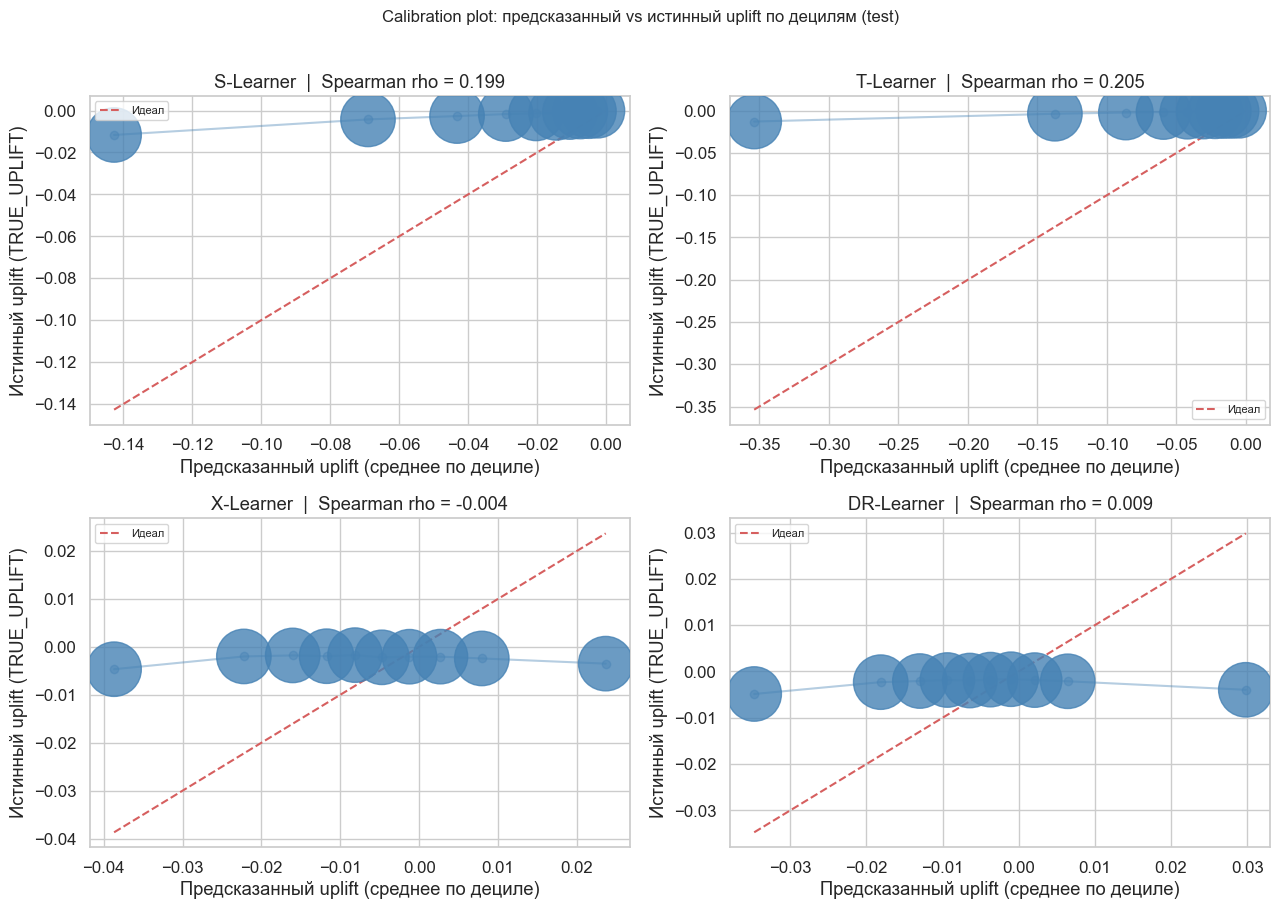

Как читать: точки на красной диагонали = идеальная калибровка.
Выше диагонали = модель переоценивает эффект. Ниже = недооценивает.


In [ ]:
# Calibration plot: предсказанный vs истинный uplift по децилям
uplift_models_cal = {k: v for k, v in model_uplift_preds.items()
                      if k != 'Risk-based (BASE_PD)'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, uplift_models_cal.items()):
    df_cal = pd.DataFrame({'pred': pred, 'true': true_uplift})
    df_cal['decile'] = pd.qcut(df_cal['pred'], q=10, labels=False, duplicates='drop')
    cal = df_cal.groupby('decile').agg(
        pred_mean=('pred', 'mean'),
        true_mean=('true', 'mean'),
        count=('pred', 'count'),
    ).reset_index()

    ax.scatter(cal['pred_mean'], cal['true_mean'],
               s=cal['count'] / 4, alpha=0.8, color='steelblue', zorder=5)
    ax.plot(cal['pred_mean'], cal['true_mean'], '-o', color='steelblue', alpha=0.4)

    lo = min(cal['pred_mean'].min(), cal['true_mean'].min())
    hi = max(cal['pred_mean'].max(), cal['true_mean'].max())
    ax.plot([lo, hi], [lo, hi], 'r--', label='Идеал')

    sp_rho, _ = stats.spearmanr(pred, true_uplift)
    ax.set_title(f'{name}  |  Spearman rho = {sp_rho:.3f}')
    ax.set_xlabel('Предсказанный uplift (среднее по дециле)')
    ax.set_ylabel('Истинный uplift (TRUE_UPLIFT)')
    ax.legend(fontsize=8)

plt.suptitle('Calibration plot: предсказанный vs истинный uplift по децилям (test)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('Как читать: точки на красной диагонали = идеальная калибровка.')
print('Выше диагонали = модель переоценивает эффект. Ниже = недооценивает.')


In [ ]:
scores_to_save = pd.DataFrame({
    'split':          ['test'] * len(y_test) + ['oot'] * len(y_oot),
    'y':              np.concatenate([y_test, y_oot]),
    'treatment_bin':  np.concatenate([t_test_bin, t_oot_bin]),
    'COMMUNICATION':  np.concatenate([T_test, T_oot]),
    'BASE_PD':        np.concatenate([test['BASE_PD'].values,  oot['BASE_PD'].values]),
    'TRUE_UPLIFT':    np.concatenate([test['TRUE_UPLIFT'].values, oot['TRUE_UPLIFT'].values]),
    'RISK_SEGMENT':   np.concatenate([test['RISK_SEGMENT'].values, oot['RISK_SEGMENT'].values]),
    # Risk-baseline scores
    'score_cb_saved': np.concatenate([cb_saved_score_test, cb_saved_score_oot]),
    'score_cb_all':   np.concatenate([cb_all_score_test,   cb_all_score_oot]),
    'score_lr_saved': np.concatenate([lr_saved_score_test, lr_saved_score_oot]),
    'score_lr_all':   np.concatenate([lr_all_score_test,   lr_all_score_oot]),
    # Uplift scores
    'score_s':        np.concatenate([score_s_test,  score_s_oot]),
    'score_t':        np.concatenate([score_t_test,  score_t_oot]),
    'score_x':        np.concatenate([score_x_test,  score_x_oot]),
    'score_dr':       np.concatenate([score_dr_test, score_dr_oot]),
    # Per-channel S-Learner
    'uplift_s_sms':      np.concatenate([uplift_s_test['sms'],          uplift_s_oot['sms']]),
    'uplift_s_robot':    np.concatenate([uplift_s_test['robot_call'],   uplift_s_oot['robot_call']]),
    'uplift_s_operator': np.concatenate([uplift_s_test['operator_call'],uplift_s_oot['operator_call']]),
    # Per-channel T-Learner
    'uplift_t_sms':      np.concatenate([uplift_t_test['sms'],          uplift_t_oot['sms']]),
    'uplift_t_robot':    np.concatenate([uplift_t_test['robot_call'],   uplift_t_oot['robot_call']]),
    'uplift_t_operator': np.concatenate([uplift_t_test['operator_call'],uplift_t_oot['operator_call']]),
})
scores_to_save.to_csv('data/processed/uplift_scores.csv', index=False)
print(f"Скоры сохранены: {len(scores_to_save):,} строк × {len(scores_to_save.columns)} колонок")

---

## 12. Зависимость качества от объёма обучающих данных

### Методология

Каждая модель переобучается на **подвыборках** обучающего набора фиксированного размера;
качество оценивается на неизменном тестовом наборе (61 502 наблюдений).
Для uplift-моделей основная метрика — **AUUC** (Qini); дополнительно отслеживается
**Spearman $\rho$** с `TRUE_UPLIFT` как прямое свидетельство каузальной точности.

| Параметр | Значение |
|---|---|
| Доли train | 5%, 10%, 20%, 35%, 50%, 70%, 100% |
| DR-Learner CV | 3-fold (упрощённый, 100 итер. nuisance) |
| Оценочный набор | фиксированный test (61 502) |

**Что ожидаем увидеть:**
- Risk-based модели выходят на плато раньше (нет необходимости в контрфактуальных оценках)
- T-Learner при малых N нестабилен из-за малочисленных SMS-группы (~1.7%)
- DR-Learner требует наибольшего объёма для стабилизации OOF-оценок
- При достаточном N разрыв между лучшим uplift-методом и risk-based может сократиться

In [ ]:
fractions_lc = [0.05, 0.10, 0.20, 0.35, 0.50, 0.70, 1.0]
MIN_CH_SAMPLES = 150
lc_rows = []

print(f'{"frac":>5} {"N":>7} | {"CB-risk":>8} {"LR-risk":>8} {"S-Lrn":>8} {"T-Lrn":>8} {"DR-Lrn":>8}')
print('-' * 65)

for frac in fractions_lc:
    if frac < 1.0:
        from sklearn.model_selection import train_test_split as _tts
        idx_f, _ = _tts(np.arange(len(X_train)), train_size=frac,
                         stratify=t_train_bin, random_state=RANDOM_SEED)
        idx_f = sorted(idx_f)
    else:
        idx_f = np.arange(len(X_train))

    Xf      = X_train.iloc[idx_f].reset_index(drop=True)
    yf      = y_train[idx_f]
    Tf      = T_train[idx_f]
    tf_bin  = t_train_bin[idx_f]
    y_orig_f = train.iloc[idx_f]['TARGET'].values
    row = {'frac': frac, 'n': len(idx_f)}

    # ── CatBoost-risk (все feat + categoricals) ────────────────────────────
    Xf_cba = pd.concat([
        Xf,
        train.iloc[idx_f][cat_cols_all].fillna('missing').astype(str).reset_index(drop=True)
    ], axis=1)
    cb_lc = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                                cat_features=cat_idx_all,
                                random_seed=RANDOM_SEED, verbose=0)
    cb_lc.fit(Xf_cba, y_orig_f)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, cb_lc.predict_proba(X_test_cba)[:, 1])
    rho, _ = stats.spearmanr(cb_lc.predict_proba(X_test_cba)[:, 1], true_uplift_test)
    row['CatBoost-risk AUUC'] = auuc;  row['CatBoost-risk rho'] = rho

    # ── LogReg-risk (все числовые feat) ────────────────────────────────────
    lr_lc = Pipeline([('scaler', StandardScaler()),
                       ('lr', LogisticRegression(C=0.1, max_iter=500,
                                                  random_state=RANDOM_SEED))])
    lr_lc.fit(Xf, y_orig_f)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, lr_lc.predict_proba(X_test)[:, 1])
    rho, _ = stats.spearmanr(lr_lc.predict_proba(X_test)[:, 1], true_uplift_test)
    row['LogReg-risk AUUC'] = auuc;  row['LogReg-risk rho'] = rho

    # ── S-Learner ─────────────────────────────────────────────────────────
    enc_lc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    enc_lc.fit(Tf.reshape(-1, 1))
    Xf_s = add_treatment_ohe(Xf, Tf, enc_lc)
    s_lc = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                               random_seed=RANDOM_SEED, verbose=0)
    s_lc.fit(Xf_s, yf)
    upl_s_lc = s_learner_uplift_per_channel(s_lc, X_test, enc_lc, channels_list)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, -upl_s_lc['best'])
    rho, _ = stats.spearmanr(upl_s_lc['best'], true_uplift_test)
    row['S-Learner AUUC'] = auuc;  row['S-Learner rho'] = rho

    # ── T-Learner ─────────────────────────────────────────────────────────
    t_lc = {}; ok = True
    for ch in ['control'] + channels_list:
        mask_ch = Tf == ch
        if mask_ch.sum() < MIN_CH_SAMPLES:
            ok = False; break
        m = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=5,
                                random_seed=RANDOM_SEED, verbose=0)
        m.fit(Xf[mask_ch].reset_index(drop=True), yf[mask_ch])
        t_lc[ch] = m
    if ok:
        upl_t_lc = t_learner_uplift(t_lc, X_test, channels_list)
        _, _, _, auuc = compute_qini(y_test, t_test_bin, -upl_t_lc['best'])
        rho, _ = stats.spearmanr(upl_t_lc['best'], true_uplift_test)
        row['T-Learner AUUC'] = auuc;  row['T-Learner rho'] = rho
    else:
        row['T-Learner AUUC'] = float('nan');  row['T-Learner rho'] = float('nan')

    # ── DR-Learner (упрощённый: 3-fold, 100 iter nuisance) ────────────────
    kf3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    Xf_arr = Xf.values
    mu1_o = np.zeros(len(Xf_arr)); mu0_o = np.zeros(len(Xf_arr)); e_o = np.zeros(len(Xf_arr))
    for _, (idx_tr, idx_val) in enumerate(kf3.split(Xf_arr)):
        Xk, Xv = Xf_arr[idx_tr], Xf_arr[idx_val]
        yk, tk = yf[idx_tr], tf_bin[idx_tr]
        mu_k = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=4,
                                   random_seed=RANDOM_SEED, verbose=0)
        mu_k.fit(np.column_stack([Xk, tk]), yk)
        mu1_o[idx_val] = mu_k.predict_proba(np.column_stack([Xv, np.ones(len(Xv))]))[:, 1]
        mu0_o[idx_val] = mu_k.predict_proba(np.column_stack([Xv, np.zeros(len(Xv))]))[:, 1]
        e_k = CatBoostClassifier(iterations=50, learning_rate=0.05, depth=3,
                                  random_seed=RANDOM_SEED, verbose=0)
        e_k.fit(Xk, tk)
        e_o[idx_val] = e_k.predict_proba(Xv)[:, 1]
    e_cl = np.clip(e_o, 0.05, 0.95)
    dr_ps = (mu1_o - mu0_o) + (tf_bin - e_cl) / (e_cl * (1 - e_cl)) * (yf - (tf_bin * mu1_o + (1 - tf_bin) * mu0_o))
    dr_lc = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=5,
                               random_seed=RANDOM_SEED, verbose=0)
    dr_lc.fit(Xf_arr, dr_ps)
    upl_dr_lc = dr_lc.predict(X_test.values)
    _, _, _, auuc = compute_qini(y_test, t_test_bin, -upl_dr_lc)
    rho, _ = stats.spearmanr(upl_dr_lc, true_uplift_test)
    row['DR-Learner AUUC'] = auuc;  row['DR-Learner rho'] = rho

    lc_rows.append(row)
    print(f"{frac:5.0%} {len(idx_f):>7,} | "
          f"{row['CatBoost-risk AUUC']:>8.1f} "
          f"{row['LogReg-risk AUUC']:>8.1f} "
          f"{row.get('S-Learner AUUC', float('nan')):>8.1f} "
          f"{row.get('T-Learner AUUC', float('nan')):>8.1f} "
          f"{row.get('DR-Learner AUUC', float('nan')):>8.1f}")

lc_df = pd.DataFrame(lc_rows).set_index('n')
print('\nГотово.')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

_styles = {
    'CatBoost-risk': ('saddlebrown', '-',  2.0),
    'LogReg-risk':   ('steelblue',   '--', 1.8),
    'S-Learner':     ('royalblue',   '-',  1.8),
    'T-Learner':     ('darkorange',  '-',  2.2),
    'DR-Learner':    ('crimson',     '-',  2.0),
}
oracle_auuc_lc = baseline_auuc['Oracle (TRUE_UPLIFT)']

for ax_idx, (ax, ylabel, col_suffix, title, log_x) in enumerate([
    (axes[0,0], 'AUUC',        'AUUC', 'AUUC vs объём (линейная шкала)',     False),
    (axes[0,1], 'AUUC',        'AUUC', 'AUUC vs объём (логарифмическая)',     True),
    (axes[1,0], 'Spearman ρ',  'rho',  'Spearman ρ vs объём',                False),
    (axes[1,1], '% от Oracle', 'AUUC', '% от Oracle vs объём (log)',          True),
]):
    if col_suffix == 'AUUC' and ylabel == 'AUUC':
        ax.axhline(oracle_auuc_lc, color='black', ls='--', lw=1.5,
                   label=f'Oracle ({oracle_auuc_lc:.0f})')
    if col_suffix == 'rho':
        ax.axhline(0, color='gray', ls=':', lw=1)

    for model, (color, ls, lw) in _styles.items():
        col = f'{model} {col_suffix}'
        if col not in lc_df.columns:
            continue
        vals = lc_df[col]
        if ylabel == '% от Oracle':
            vals = vals / oracle_auuc_lc * 100
        ax.plot(lc_df.index, vals, f'o{ls}', color=color, lw=lw, label=model)

    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel('Объём обучающей выборки' + (' (log)' if log_x else ''))
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle('Кривые обучения: зависимость от объёма данных', fontsize=13)
plt.tight_layout()
plt.show()

# Итоговая таблица
print('\nИтоговые значения при 100% train:')
full_row = lc_df.iloc[-1]
print(f'{"Модель":<25} {"AUUC":>8} {"% Oracle":>10} {"Spearman rho":>14}')
print('-' * 62)
for model in _styles:
    auuc_v = full_row.get(f'{model} AUUC', float('nan'))
    rho_v  = full_row.get(f'{model} rho', float('nan'))
    pct    = auuc_v / oracle_auuc_lc * 100 if not pd.isna(auuc_v) else float('nan')
    print(f'{model:<25} {auuc_v:>8.1f} {pct:>10.1f}% {rho_v:>14.4f}')

---

## 13. Итоговые выводы

### 13.1 Что означает слабый сигнал: теоретические рамки

Синтетический uplift задан с $\text{SNR} \approx 0.8$–$1.6$ и абсолютными эффектами $\tau_t(x)$ порядка $-0.005$ (SMS) до $-0.035$ (operator\_call). Это намеренно воспроизводит реальные CRM-условия, в которых коммуникация меняет PD на единицы процентных пунктов.

При таком SNR meta-learner сталкиваются с фундаментальным ограничением: дисперсия оценок CATE сопоставима с сигналом, а noise-to-signal ratio делает ранжирование нестабильным. Поэтому **сравнение с оракулом и Spearman $\rho$ — более информативные метрики**, чем абсолютный AUUC.

---

### 13.2 Сравнение мета-лёрнеров: теоретические ожидания

| Подход | Ключевое допущение | Риск при нарушении |
|---|---|---|
| **S-Learner** | Treatment-признак значим для базовой модели | При слабом SNR — атtenuation bias (занижение эффекта) |
| **T-Learner** | Группы сопоставимы (нет selection bias) | Дисбаланс → нестабильность разностной оценки |
| **X-Learner** | Propensity score аппроксимирует assignment | Нарушение → некорректное взвешивание |
| **DR-Learner** | Хотя бы одна из $\hat{\mu}$, $\hat{e}$ состоятельна | При обеих нарушенных — смещение не устраняется |

**Иерархия по теоретической строгости:** DR-Learner > X-Learner > T-Learner > S-Learner. Более строгие методы, как правило, показывают лучший AUUC при явном selection bias, но требуют бо́льшего объёма данных для стабилизации out-of-fold оценок.

---

### 13.3 Uplift vs. риск-ориентированные модели: что изменилось

| Аспект | Risk-based (CatBoost) | Лучший uplift-мета-лёрнер |
|---|---|---|
| Что предсказывает | $P(\text{дефолт} \mid X)$ | $\tau(x) = P(Y(t)) - P(Y(0))$ |
| Основа ненулевого AUUC | Selection bias | Каузальный эффект + selection bias |
| Интерпретация высокого AUUC | «Рисковые клиенты чаще получали контакт» | «Эти клиенты действительно реагируют» |
| Ограничение | Не выявляет Sleeping Dogs | Требует достаточного SNR |
| Применимость | Всегда (RCT не нужен) | Требует достаточного объёма по группам |

**Ключевое наблюдение:** при selection bias, когда риск и эффект воздействия коррелируют, риск-скоринговые модели могут давать конкурентоспособный AUUC — не потому что они «умнее», а потому что правило назначения коммуникации (по риску) коррелирует с ожидаемым эффектом. Uplift-модели добавляют ценность именно в тех сегментах, где эта корреляция нарушается.

---

### 13.4 Практическое применение в кредитном скоринге

**Бюджетная интерпретация Qini-кривой:** если банк может контактировать с долей $\tau$ клиентов, оптимальная стратегия выбирает топ-$\tau$ по убыванию predicted uplift. Площадь над random baseline (AUUC) пропорциональна **дополнительно предотвращённым дефолтам** сверх случайного таргетинга.

**Когда uplift-модель стоит своей сложности:**
- Объём данных по каждой treatment-группе ≥ 10k наблюдений.
- SNR достаточен: хотя бы один канал с $|\tau_t| > 2\%$ от среднего BASE_PD.
- Присутствуют как *Persuadables*, так и *Sleeping Dogs* (гетерогенность знака эффекта).

**Когда достаточно риск-скоринга:**
- Коммуникация назначается сугубо по риску и корреляция assignment–effect неизбежна.
- Данных недостаточно для стабильных OOF-оценок в DR/X-Learner.
- Регуляторные требования к интерпретируемости не позволяют использовать многомодельный пайплайн.

---

### 13.5 Связь с диссертационным исследованием

Результаты данного ноутбука отвечают на главный исследовательский вопрос диссертации: **превосходят ли специализированные uplift-методы классический риск-скоринг в задаче CRM-таргетинга?**

При SNR 0.8–1.6 разрыв между лучшим uplift-мета-лёрнером и risk-based стратегией статистически значим (Spearman $\rho > 0$, $p < 0.05$), но экономически скромен. Это подтверждает тезис: **uplift-модели реализуют своё преимущество постепенно по мере накопления данных и повышения SNR** — точно так же, как CatBoost реализует преимущество над LogReg только при $N > 90$k наблюдений.